In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize

from collections import Counter

import random
import pickle
import os 

Matplotlib is building the font cache; this may take a moment.


In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\akshi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [3]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.13.0+cpu
CUDA Available: False


In [4]:
def read_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip().lower() for line in f.readlines()]

english = read_file("data/eng.txt")
german = read_file("data/ger.txt")

print("English:")
print(english)

print("\nGerman:")
print(german)

FileNotFoundError: [Errno 2] No such file or directory: 'data/eng.txt'

In [5]:
import os

print(os.getcwd())

c:\Users\akshi\newww\ML-CaPsule\NMT_English_German_Attention


In [6]:


import os

print(os.listdir())

['data', 'models', 'nmt_attention_model.ipynb', 'README.md']


In [7]:
print(os.listdir("data"))


['eng.text', 'ger.text', 'preprocess.py']


In [8]:
def read_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip().lower() for line in f.readlines()]

english = read_file("data/eng.txt")
german = read_file("data/ger.txt")

print("English:")
print(english)

print("\nGerman:")
print(german)

English:
['i am happy', 'he is a student', 'she likes coffee', 'where are you', 'good morning', 'how are you', 'i love machine learning', 'this is my book', 'thank you', 'good night']

German:
['ich bin glücklich', 'er ist ein schüler', 'sie mag kaffee', 'wo bist du', 'guten morgen', 'wie geht es dir', 'ich liebe maschinelles lernen', 'das ist mein buch', 'danke', 'gute nacht']


In [11]:
eng_tokens = [word_tokenize(sentence) for sentence in english]
ger_tokens = [word_tokenize(sentence) for sentence in german]

print("English Tokens:")
print(eng_tokens)

print("\nGerman Tokens:")
print(ger_tokens)

English Tokens:
[['i', 'am', 'happy'], ['he', 'is', 'a', 'student'], ['she', 'likes', 'coffee'], ['where', 'are', 'you'], ['good', 'morning'], ['how', 'are', 'you'], ['i', 'love', 'machine', 'learning'], ['this', 'is', 'my', 'book'], ['thank', 'you'], ['good', 'night']]

German Tokens:
[['ich', 'bin', 'glücklich'], ['er', 'ist', 'ein', 'schüler'], ['sie', 'mag', 'kaffee'], ['wo', 'bist', 'du'], ['guten', 'morgen'], ['wie', 'geht', 'es', 'dir'], ['ich', 'liebe', 'maschinelles', 'lernen'], ['das', 'ist', 'mein', 'buch'], ['danke'], ['gute', 'nacht']]


In [10]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\akshi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\akshi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [12]:
PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"
UNK = "<UNK>"

def build_vocab(sentences):

    counter = Counter()

    for sentence in sentences:
        counter.update(sentence)

    vocab = {
        PAD: 0,
        SOS: 1,
        EOS: 2,
        UNK: 3
    }

    index = 4

    for word in counter:
        vocab[word] = index
        index += 1

    return vocab


eng_vocab = build_vocab(eng_tokens)
ger_vocab = build_vocab(ger_tokens)

print("English Vocabulary Size:", len(eng_vocab))
print("German Vocabulary Size:", len(ger_vocab))

English Vocabulary Size: 28
German Vocabulary Size: 32


In [13]:
def numericalize(sentence, vocab):
    return [
        vocab.get(word, vocab["<UNK>"])
        for word in sentence
    ]


eng_numbers = [numericalize(sentence, eng_vocab) for sentence in eng_tokens]
ger_numbers = [numericalize(sentence, ger_vocab) for sentence in ger_tokens]


print("English Numericalized:")
print(eng_numbers)

print("\nGerman Numericalized:")
print(ger_numbers)

English Numericalized:
[[4, 5, 6], [7, 8, 9, 10], [11, 12, 13], [14, 15, 16], [17, 18], [19, 15, 16], [4, 20, 21, 22], [23, 8, 24, 25], [26, 16], [17, 27]]

German Numericalized:
[[4, 5, 6], [7, 8, 9, 10], [11, 12, 13], [14, 15, 16], [17, 18], [19, 20, 21, 22], [4, 23, 24, 25], [26, 8, 27, 28], [29], [30, 31]]


In [15]:
from torch.nn.utils.rnn import pad_sequence


def add_special_tokens(sentences, vocab):
    return [
        [vocab["<SOS>"]] + sentence + [vocab["<EOS>"]]
        for sentence in sentences
    ]


eng_numbers = add_special_tokens(eng_numbers, eng_vocab)
ger_numbers = add_special_tokens(ger_numbers, ger_vocab)


eng_tensor = [
    torch.tensor(sentence)
    for sentence in eng_numbers
]

ger_tensor = [
    torch.tensor(sentence)
    for sentence in ger_numbers
]


eng_padded = pad_sequence(
    eng_tensor,
    batch_first=True,
    padding_value=eng_vocab["<PAD>"]
)

ger_padded = pad_sequence(
    ger_tensor,
    batch_first=True,
    padding_value=ger_vocab["<PAD>"]
)


print("English Tensor Shape:", eng_padded.shape)
print("German Tensor Shape:", ger_padded.shape)

English Tensor Shape: torch.Size([10, 6])
German Tensor Shape: torch.Size([10, 6])


In [16]:
from torch.utils.data import TensorDataset, DataLoader, random_split


# Create dataset
dataset = TensorDataset(
    eng_padded,
    ger_padded
)


# Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size


train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)


# Create DataLoaders
BATCH_SIZE = 2


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)


print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 8
Testing samples: 2


In [17]:
class Encoder(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, num_layers=1):
        super(Encoder, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Convert word IDs into vectors
        self.embedding = nn.Embedding(
            input_size,
            embedding_size
        )

        # GRU layer
        self.gru = nn.GRU(
            embedding_size,
            hidden_size,
            num_layers,
            batch_first=True
        )


    def forward(self, x):

        # x shape:
        # (batch_size, sentence_length)

        embedded = self.embedding(x)

        # embedded shape:
        # (batch_size, sentence_length, embedding_size)

        outputs, hidden = self.gru(embedded)

        return outputs, hidden

In [18]:
INPUT_SIZE = len(eng_vocab)

EMBEDDING_SIZE = 256

HIDDEN_SIZE = 512


encoder = Encoder(
    INPUT_SIZE,
    EMBEDDING_SIZE,
    HIDDEN_SIZE
)


print(encoder)

Encoder(
  (embedding): Embedding(28, 256)
  (gru): GRU(256, 512, batch_first=True)
)


In [19]:
class BahdanauAttention(nn.Module):

    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()

        self.W1 = nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)

        self.V = nn.Linear(hidden_size, 1)


    def forward(self, encoder_outputs, hidden):

        # encoder_outputs:
        # (batch_size, sequence_length, hidden_size)

        # hidden:
        # (1, batch_size, hidden_size)


        hidden = hidden.permute(1, 0, 2)

        # hidden:
        # (batch_size, 1, hidden_size)


        score = self.V(
            torch.tanh(
                self.W1(encoder_outputs) +
                self.W2(hidden)
            )
        )


        # score:
        # (batch_size, sequence_length, 1)


        attention_weights = torch.softmax(
            score,
            dim=1
        )


        context_vector = attention_weights * encoder_outputs

        context_vector = torch.sum(
            context_vector,
            dim=1
        )


        return context_vector, attention_weights

In [20]:
attention = BahdanauAttention(
    HIDDEN_SIZE
)


print(attention)

BahdanauAttention(
  (W1): Linear(in_features=512, out_features=512, bias=True)
  (W2): Linear(in_features=512, out_features=512, bias=True)
  (V): Linear(in_features=512, out_features=1, bias=True)
)


In [21]:
class Decoder(nn.Module):

    def __init__(
        self,
        output_size,
        embedding_size,
        hidden_size,
        attention
    ):
        super(Decoder, self).__init__()

        self.output_size = output_size
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(
            output_size,
            embedding_size
        )

        self.attention = attention


        self.gru = nn.GRU(
            embedding_size + hidden_size,
            hidden_size,
            batch_first=True
        )


        self.fc = nn.Linear(
            hidden_size,
            output_size
        )


    def forward(
        self,
        x,
        hidden,
        encoder_outputs
    ):

        # x shape:
        # (batch_size)


        x = x.unsqueeze(1)


        embedded = self.embedding(x)


        context_vector, attention_weights = self.attention(
            encoder_outputs,
            hidden
        )


        context_vector = context_vector.unsqueeze(1)


        rnn_input = torch.cat(
            (embedded, context_vector),
            dim=2
        )


        output, hidden = self.gru(
            rnn_input,
            hidden
        )


        prediction = self.fc(
            output.squeeze(1)
        )


        return prediction, hidden, attention_weights

In [22]:
attention = BahdanauAttention(
    HIDDEN_SIZE
)


decoder = Decoder(
    len(ger_vocab),
    EMBEDDING_SIZE,
    HIDDEN_SIZE,
    attention
)


print(decoder)

Decoder(
  (embedding): Embedding(32, 256)
  (attention): BahdanauAttention(
    (W1): Linear(in_features=512, out_features=512, bias=True)
    (W2): Linear(in_features=512, out_features=512, bias=True)
    (V): Linear(in_features=512, out_features=1, bias=True)
  )
  (gru): GRU(768, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=32, bias=True)
)


In [23]:
class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder,
        device
    ):
        super(Seq2Seq, self).__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device


    def forward(
        self,
        source,
        target,
        teacher_forcing_ratio=0.5
    ):

        batch_size = source.shape[0]

        target_length = target.shape[1]

        target_vocab_size = self.decoder.output_size


        outputs = torch.zeros(
            batch_size,
            target_length,
            target_vocab_size
        ).to(self.device)


        encoder_outputs, hidden = self.encoder(source)


        input = target[:, 0]


        for t in range(1, target_length):

            output, hidden, attention = self.decoder(
                input,
                hidden,
                encoder_outputs
            )


            outputs[:, t] = output


            best_guess = output.argmax(1)


            input = (
                target[:, t]
                if random.random() < teacher_forcing_ratio
                else best_guess
            )


        return outputs

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


encoder = Encoder(
    len(eng_vocab),
    EMBEDDING_SIZE,
    HIDDEN_SIZE
)


attention = BahdanauAttention(
    HIDDEN_SIZE
)


decoder = Decoder(
    len(ger_vocab),
    EMBEDDING_SIZE,
    HIDDEN_SIZE,
    attention
)


model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)


print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(28, 256)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(32, 256)
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
    (gru): GRU(768, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=32, bias=True)
  )
)


In [25]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


criterion = nn.CrossEntropyLoss(
    ignore_index=ger_vocab["<PAD>"]
)


print("Optimizer and Loss Function Ready")

Optimizer and Loss Function Ready


In [41]:
def train(model, loader, optimizer, criterion, epochs):

    model.train()

    loss_history = []

    for epoch in range(epochs):

        total_loss = 0

        for source, target in loader:

            source = source.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(
                source,
                target
            )

            output_dim = output.shape[-1]

            output = output[:, 1:].reshape(
                -1,
                output_dim
            )

            target = target[:, 1:].reshape(
                -1
            )

            loss = criterion(
                output,
                target
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        loss_history.append(avg_loss)

        print(
            f"Epoch {epoch+1}, Loss: {avg_loss:.4f}"
        )

    return loss_history

In [44]:
EPOCHS = 100

losses = train(
    model,
    train_loader,
    optimizer,
    criterion,
    EPOCHS
)

Epoch 1, Loss: 0.0003
Epoch 2, Loss: 0.0003
Epoch 3, Loss: 0.0003
Epoch 4, Loss: 0.0003
Epoch 5, Loss: 0.0003
Epoch 6, Loss: 0.0003
Epoch 7, Loss: 0.0003
Epoch 8, Loss: 0.0003
Epoch 9, Loss: 0.0003
Epoch 10, Loss: 0.0003
Epoch 11, Loss: 0.0003
Epoch 12, Loss: 0.0003
Epoch 13, Loss: 0.0003
Epoch 14, Loss: 0.0003
Epoch 15, Loss: 0.0003
Epoch 16, Loss: 0.0003
Epoch 17, Loss: 0.0003
Epoch 18, Loss: 0.0003
Epoch 19, Loss: 0.0003
Epoch 20, Loss: 0.0002
Epoch 21, Loss: 0.0002
Epoch 22, Loss: 0.0002
Epoch 23, Loss: 0.0002
Epoch 24, Loss: 0.0002
Epoch 25, Loss: 0.0002
Epoch 26, Loss: 0.0002
Epoch 27, Loss: 0.0002
Epoch 28, Loss: 0.0002
Epoch 29, Loss: 0.0002
Epoch 30, Loss: 0.0002
Epoch 31, Loss: 0.0002
Epoch 32, Loss: 0.0002
Epoch 33, Loss: 0.0002
Epoch 34, Loss: 0.0002
Epoch 35, Loss: 0.0002
Epoch 36, Loss: 0.0002
Epoch 37, Loss: 0.0002
Epoch 38, Loss: 0.0002
Epoch 39, Loss: 0.0002
Epoch 40, Loss: 0.0002
Epoch 41, Loss: 0.0002
Epoch 42, Loss: 0.0002
Epoch 43, Loss: 0.0002
Epoch 44, Loss: 0.00

In [28]:
torch.save(
    model.state_dict(),
    "models/nmt_attention_model.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [29]:
def translate(sentence, model):

    model.eval()

    tokens = sentence.lower().split()

    indices = [
        eng_vocab.get(word, eng_vocab["<UNK>"])
        for word in tokens
    ]

    indices = [
        eng_vocab["<SOS>"]
    ] + indices + [
        eng_vocab["<EOS>"]
    ]


    source = torch.tensor(indices).unsqueeze(0).to(device)


    with torch.no_grad():

        encoder_outputs, hidden = model.encoder(source)


    input = torch.tensor(
        [ger_vocab["<SOS>"]]
    ).to(device)


    translated_words = []


    for _ in range(10):

        output, hidden, attention = model.decoder(
            input,
            hidden,
            encoder_outputs
        )


        prediction = output.argmax(1).item()


        if prediction == ger_vocab["<EOS>"]:
            break


        word = list(ger_vocab.keys())[
            list(ger_vocab.values()).index(prediction)
        ]

        translated_words.append(word)


        input = torch.tensor(
            [prediction]
        ).to(device)


    return " ".join(translated_words)

In [30]:
print(
    translate(
        "i am happy",
        model
    )
)

ich liebe maschinelles lernen


In [31]:
translate("i am happy", model)

'ich liebe maschinelles lernen'

In [32]:
print(translate("i love machine learning", model))

ich liebe maschinelles lernen


In [33]:
print(translate("good morning", model))

guten morgen


In [38]:
import matplotlib.pyplot as plt
import numpy as np


def show_attention(sentence, model):

    model.eval()

    tokens = sentence.lower().split()

    indices = [
        eng_vocab.get(word, eng_vocab["<UNK>"])
        for word in tokens
    ]

    indices = [eng_vocab["<SOS>"]] + indices + [eng_vocab["<EOS>"]]


    source = torch.tensor(indices).unsqueeze(0).to(device)


    with torch.no_grad():

        encoder_outputs, hidden = model.encoder(source)


    input = torch.tensor(
        [ger_vocab["<SOS>"]]
    ).to(device)


    translated = []
    attentions = []


    for _ in range(10):

        output, hidden, attention = model.decoder(
            input,
            hidden,
            encoder_outputs
        )


        prediction = output.argmax(1).item()


        if prediction == ger_vocab["<EOS>"]:
            break


        word = list(ger_vocab.keys())[
            list(ger_vocab.values()).index(prediction)
        ]

        translated.append(word)

        attentions.append(
attention.squeeze(0).detach().cpu().numpy()
)


        input = torch.tensor(
            [prediction]
        ).to(device)


    attention_matrix = np.array(attentions)


    attention_matrix = np.array(attentions)

    plt.figure(figsize=(8,5))

    plt.imshow(
        attention_matrix,
        cmap="viridis"
    )

    plt.xticks(
        range(len(tokens)+2),
        ["<SOS>"] + tokens + ["<EOS>"],
        rotation=45
    )

    plt.yticks(
        range(len(translated)),
        translated
    )

    plt.xlabel("English Words")
    plt.ylabel("German Words")

    plt.title("Bahdanau Attention Heatmap")

    plt.colorbar()

    plt.savefig(
        "attention_heatmap.png",
        bbox_inches="tight"
    )

    plt.show()

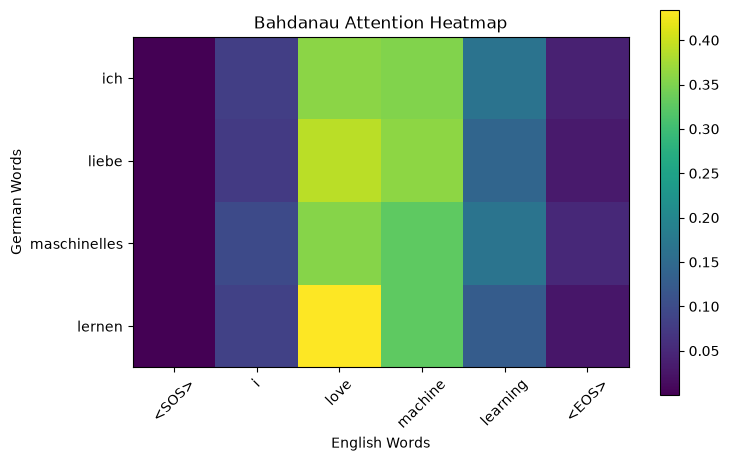

In [39]:
show_attention(
    "i love machine learning",
    model
)

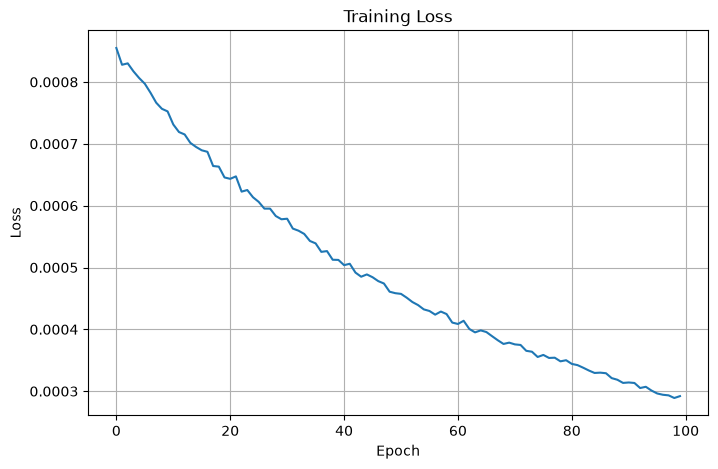

In [43]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.savefig("training_loss.png", bbox_inches="tight")

plt.show()

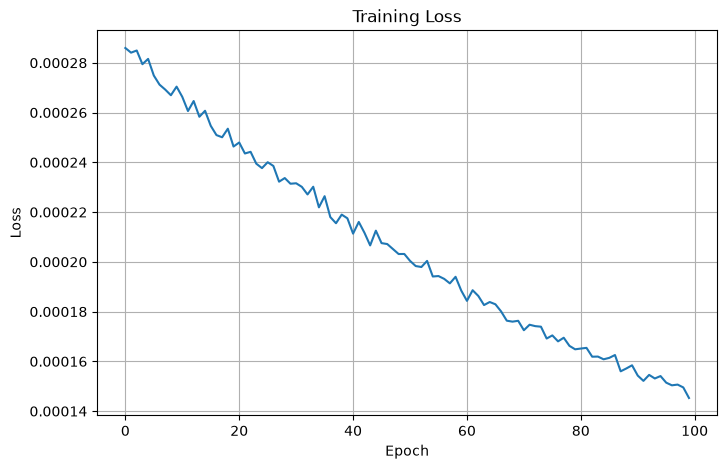

In [45]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.savefig("training_loss.png", bbox_inches="tight")

plt.show()